# L13 — Spin Echo vs Gradient Echo
### Module 3 · Day 19 · MRI1 Lecture 13 (FAU Erlangen-Nürnberg, WS23/24)

This notebook turns Lecture 13 into runnable code. We build, from synthetic data:

1. **Phase dispersion** in a voxel — the "sum of arrows" that creates signal loss
2. **`T₂'` from a frequency distribution** — and *why* `exp(−t/T₂')` is only an approximation
3. **`T₂`, `T₂'`, `T₂*`** — the nesting of decay envelopes and the rate-addition law
4. **The spin echo** — refocusing `T₂'`, reproducing the classic FID-plus-echo figure
5. **SE vs GRE** — how the contrast at `TE` differs
6. **Exercise 13.1** — voxel signal of a linear `ΔB_z` (it's a *sinc*, not an exponential!)
7. **Exercise 13.2** — a 180° pulse reflects k-space (`k → −k`)

> **How to use:** run top to bottom. Then *break things* — change the off-resonance spread, the
> echo time, the voxel size — and watch the physics respond.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1H gyromagnetic ratio
GAMMA      = 2.675222e8      # rad / (s * T)
GAMMA_BAR  = GAMMA / (2*np.pi)   # Hz / T  (= 42.577 MHz/T)
print(f"gamma/2pi = {GAMMA_BAR/1e6:.3f} MHz/T")

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.figsize": (8, 4)})
rng = np.random.default_rng(13)

gamma/2pi = 42.577 MHz/T


## 1 · Phase dispersion in a voxel — "sum of arrows"

A local field offset `ΔB_z(r)` gives a local frequency offset and hence a growing phase:

$$\Delta\omega(\mathbf r)=\gamma\,\Delta B_z(\mathbf r),\qquad
\Delta\varphi(\mathbf r,t)=\Delta\omega(\mathbf r)\,t .$$

Each spin packet is a complex "arrow" `M'⊥ = |M'⊥|·e^{iφ}`. The signal is the **vector sum** of all
arrows. We reproduce the lecture's four-spin example (`ΔB_z = +3, +1, −1, −3 µT`): as time runs the
arrows fan out, partially cancel, and the signal shrinks.

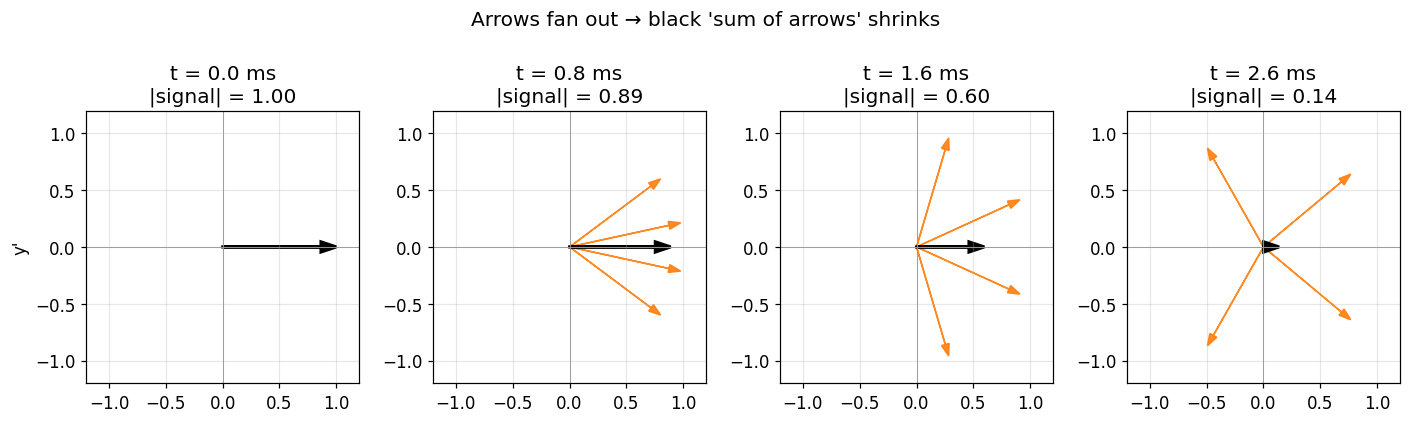

In [2]:
# The four lecture spins (same |M'_perp|, different off-resonance)
dBz = np.array([3, 1, -1, -3]) * 1e-6      # tesla
domega = GAMMA * dBz                        # rad/s

def arrows_at(t):
    return np.exp(1j * domega * t)          # unit arrows, phase = domega*t

times = [0.0, 0.8e-3, 1.6e-3, 2.6e-3]       # snapshots in seconds
fig, axes = plt.subplots(1, len(times), figsize=(13, 3.4))
for ax, t in zip(axes, times):
    arr = arrows_at(t)
    for a in arr:
        ax.arrow(0, 0, a.real, a.imag, head_width=0.07, length_includes_head=True,
                 color="tab:orange", alpha=0.9)
    s = arr.mean()                          # the "sum of arrows" (normalised)
    ax.arrow(0, 0, s.real, s.imag, head_width=0.09, length_includes_head=True,
             color="black", lw=2)
    ax.set_title(f"t = {t*1e3:.1f} ms\n|signal| = {abs(s):.2f}")
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect("equal")
    ax.axhline(0, color="0.6", lw=0.6); ax.axvline(0, color="0.6", lw=0.6)
axes[0].set_ylabel("y'"); 
fig.suptitle("Arrows fan out → black 'sum of arrows' shrinks", y=1.06)
plt.tight_layout(); plt.show()

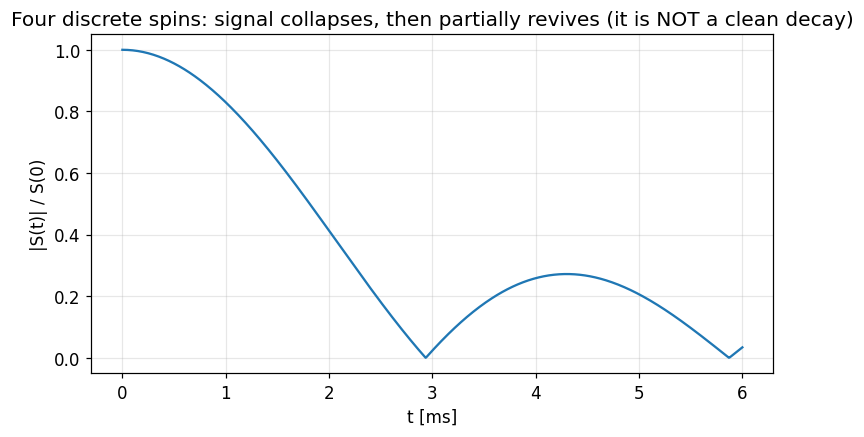

Note the revivals: only a *continuous, broad* distribution gives smooth monotone decay.


In [3]:
# Magnitude of the summed signal vs time for the 4-spin toy voxel
t = np.linspace(0, 6e-3, 600)
S = np.abs(np.mean(np.exp(1j*np.outer(t, domega)), axis=1))
plt.figure()
plt.plot(t*1e3, S, color="tab:blue")
plt.xlabel("t [ms]"); plt.ylabel("|S(t)| / S(0)")
plt.title("Four discrete spins: signal collapses, then partially revives (it is NOT a clean decay)")
plt.show()
print("Note the revivals: only a *continuous, broad* distribution gives smooth monotone decay.")

## 2 · `T₂'` from a distribution of off-resonances

For a continuous distribution `P(Δω)` of off-resonances inside a voxel, the (relaxation-free) FID is

$$S(t)=S(0)\int P(\Delta\omega)\,e^{i\,\Delta\omega\,t}\,d(\Delta\omega),$$

i.e. **the Fourier transform of the line shape**. This is the key to the lecture's footnote that
`exp(−t/T₂')` is only an *approximation*:

| line shape `P(Δω)` | resulting `\|S(t)\|` |
|---|---|
| **Lorentzian** | **exponential** `exp(−t/T₂')` ✅ |
| Gaussian | Gaussian `exp(−t²/2τ²)` |
| **uniform / box** (linear gradient across a box voxel) | **sinc** — oscillates, goes negative! |

So the exponential is exact *only* for a Lorentzian spread. We'll see the box case again in
Exercise 13.1.

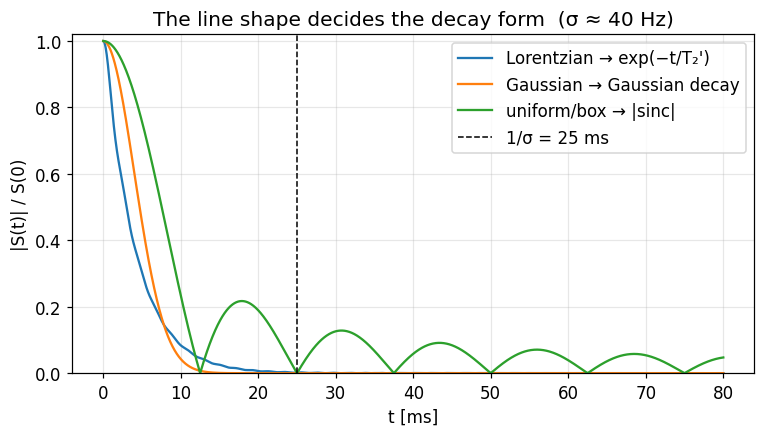

In [4]:
t = np.linspace(0, 80e-3, 2000)         # 0..80 ms
sigma_f = 40.0                          # Hz  (the pop-quiz width)
sigma_w = 2*np.pi*sigma_f               # rad/s

# Sample each distribution and Fourier-sum
w = np.linspace(-12*sigma_w, 12*sigma_w, 20001)
dw = w[1]-w[0]
def fid(P):
    P = P/np.trapezoid(P, w)            # normalise
    return np.abs(np.trapezoid(P[None,:]*np.exp(1j*np.outer(t, w)), w, axis=1))

P_lor   = (sigma_w/np.pi)/(w**2 + sigma_w**2)          # Lorentzian (HWHM = sigma_w)
P_gauss = np.exp(-w**2/(2*sigma_w**2))
halfw   = sigma_w
P_box   = (np.abs(w) <= halfw).astype(float)

plt.figure()
plt.plot(t*1e3, fid(P_lor),   label="Lorentzian → exp(−t/T₂')")
plt.plot(t*1e3, fid(P_gauss), label="Gaussian → Gaussian decay")
plt.plot(t*1e3, np.abs(fid(P_box)), label="uniform/box → |sinc|")
plt.axvline(1e3/sigma_f, color="k", ls="--", lw=1, label=f"1/σ = {1e3/sigma_f:.0f} ms")
plt.xlabel("t [ms]"); plt.ylabel("|S(t)| / S(0)"); plt.ylim(0, 1.02)
plt.legend(); plt.title("The line shape decides the decay form  (σ ≈ 40 Hz)")
plt.show()

In [5]:
# Pop-quiz check: width sigma_f ~= 40 Hz  ->  T2' ~= 1/40 Hz = 25 ms
T2p_estimate = 1.0/sigma_f
print(f"Pop quiz:  T2' ~ 1/sigma  = 1/{sigma_f:.0f} Hz = {T2p_estimate*1e3:.0f} ms")
print("Matches the lecture's answer of 25 ms (option: 25 ms).")

Pop quiz:  T2' ~ 1/sigma  = 1/40 Hz = 25 ms
Matches the lecture's answer of 25 ms (option: 25 ms).


## 3 · `T₂`, `T₂'`, `T₂*` — rates add

Two attenuations act at once: reversible `T₂'` (from static `ΔB`) and irreversible `T₂`.
**Rates add**, so `T₂*` is always the fastest:

$$R_2^{*}=R_2+R_2',\qquad \frac1{T_2^{*}}=\frac1{T_2}+\frac1{T_2'},\qquad
S(t)=S(0)\,e^{-t/T_2^{*}} .$$

T2  = 80.0 ms
T2' = 25.0 ms
T2* = 19.0 ms  (fastest, as expected)


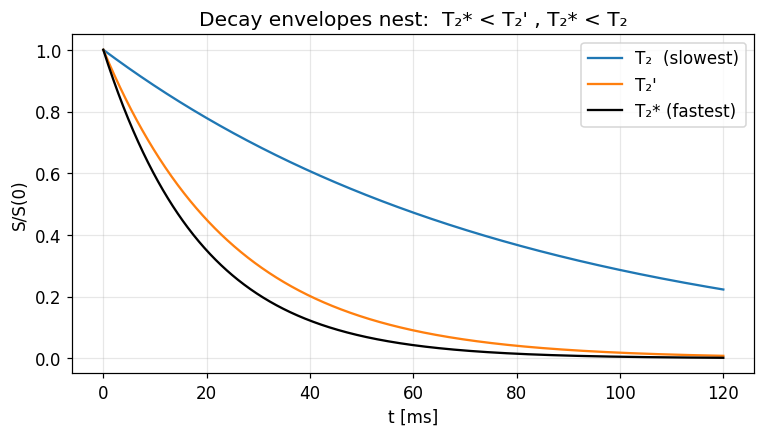

In [6]:
T2  = 80e-3      # s   (intrinsic)
T2p = 25e-3      # s   (from off-resonance, matches Section 2)
T2s = 1.0/(1.0/T2 + 1.0/T2p)
print(f"T2  = {T2*1e3:.1f} ms\nT2' = {T2p*1e3:.1f} ms\nT2* = {T2s*1e3:.1f} ms  (fastest, as expected)")

t = np.linspace(0, 120e-3, 1000)
plt.figure()
plt.plot(t*1e3, np.exp(-t/T2),  label="T₂  (slowest)")
plt.plot(t*1e3, np.exp(-t/T2p), label="T₂'")
plt.plot(t*1e3, np.exp(-t/T2s), label="T₂* (fastest)", color="k")
plt.xlabel("t [ms]"); plt.ylabel("S/S(0)"); plt.legend()
plt.title("Decay envelopes nest:  T₂* < T₂' , T₂* < T₂")
plt.show()

## 4 · The spin echo

Recipe: **90° → wait `TE/2` → 180° → wait `TE/2` → echo at `TE`**.

We simulate many *isochromats* (spin packets with a Gaussian spread of static off-resonances) and
*also* give them an intrinsic `T₂`. The 180° pulse about `x'` conjugates the transverse
magnetization (`M₊ → M₊*`), i.e. it flips every accumulated phase `Δφ → −Δφ`. The deterministic
`T₂'` dephasing then unwinds and rebuilds the signal into an **echo at `TE`** — but the random `T₂`
decay is *not* recovered, so the echo peak sits on the `T₂` envelope.

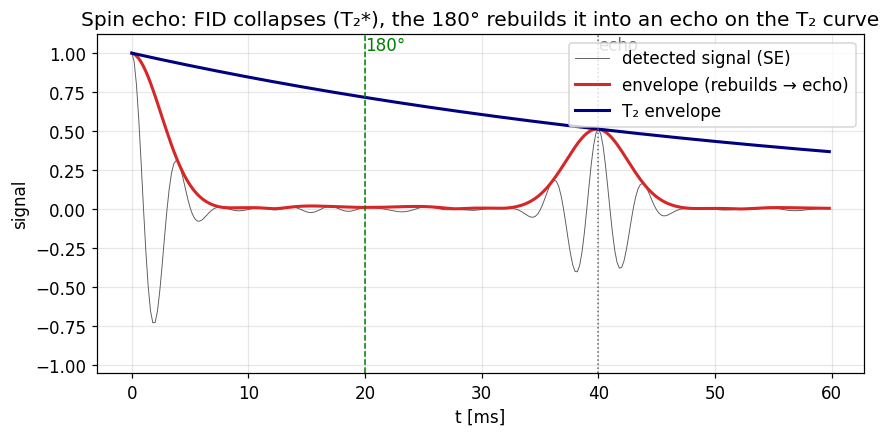

Echo amplitude at TE  = 0.513
T2 prediction exp(-TE/T2) = 0.513   <-- echo follows T2, not T2*


In [7]:
# Isochromat ensemble
N      = 4000
sig_f  = 60.0                       # Hz spread of static off-resonance
domega = 2*np.pi*sig_f*rng.standard_normal(N)   # rad/s, fixed per spin
T2     = 60e-3
TE     = 40e-3                      # echo time
fs     = 5000.0                     # 'sampling' for a visible carrier
t      = np.arange(0, 1.5*TE, 1/fs)

def transverse(t, flipped_at=None):
    # phase from static off-resonance; 180° about x' negates phase accrued so far
    if flipped_at is None:
        phase = np.outer(t, domega)
    else:
        pre  = np.clip(t, 0, flipped_at)
        post = np.clip(t-flipped_at, 0, None)
        phase = np.outer(post-pre, domega)        # -domega*pre + domega*post
    decay = np.exp(-t/T2)[:, None]                # intrinsic T2 (NOT refocused)
    return (decay * np.exp(1j*phase)).mean(axis=1)

S_fid = transverse(t)                  # no 180° : free induction decay (T2*)
S_se  = transverse(t, flipped_at=TE/2) # with 180° at TE/2 : spin echo

# add a visible carrier just for the 'oscillating signal' look of the slide
carrier = np.exp(1j*2*np.pi*250*t)
plt.figure(figsize=(9,4))
plt.plot(t*1e3, np.real(S_se*carrier), lw=0.6, color="0.35", label="detected signal (SE)")
plt.plot(t*1e3,  np.abs(S_se),  color="tab:red",  lw=2, label="envelope (rebuilds → echo)")
plt.plot(t*1e3,  np.exp(-t/T2), color="navy", lw=2, label="T₂ envelope")
plt.axvline(TE/2*1e3, color="green", ls="--", lw=1); plt.text(TE/2*1e3, 1.02, "180°", color="green")
plt.axvline(TE*1e3,   color="0.4",  ls=":",  lw=1); plt.text(TE*1e3, 1.02, "echo", color="0.4")
plt.xlabel("t [ms]"); plt.ylabel("signal"); plt.ylim(-1.05, 1.12); plt.legend(loc="upper right")
plt.title("Spin echo: FID collapses (T₂*), the 180° rebuilds it into an echo on the T₂ curve")
plt.show()

print(f"Echo amplitude at TE  = {np.interp(TE, t, np.abs(S_se)):.3f}")
print(f"T2 prediction exp(-TE/T2) = {np.exp(-TE/T2):.3f}   <-- echo follows T2, not T2*")

## 5 · SE vs GRE — contrast at the echo

A **gradient echo** has no 180°, so its signal at `TE` decays with `T₂*`; the **spin echo** decays
with `T₂`. At air–tissue interfaces `T₂'` (hence `T₂*`) is short, so the GRE loses signal there —
the dark-sinus look. Below: signal at `TE` for a few tissues, SE vs GRE.

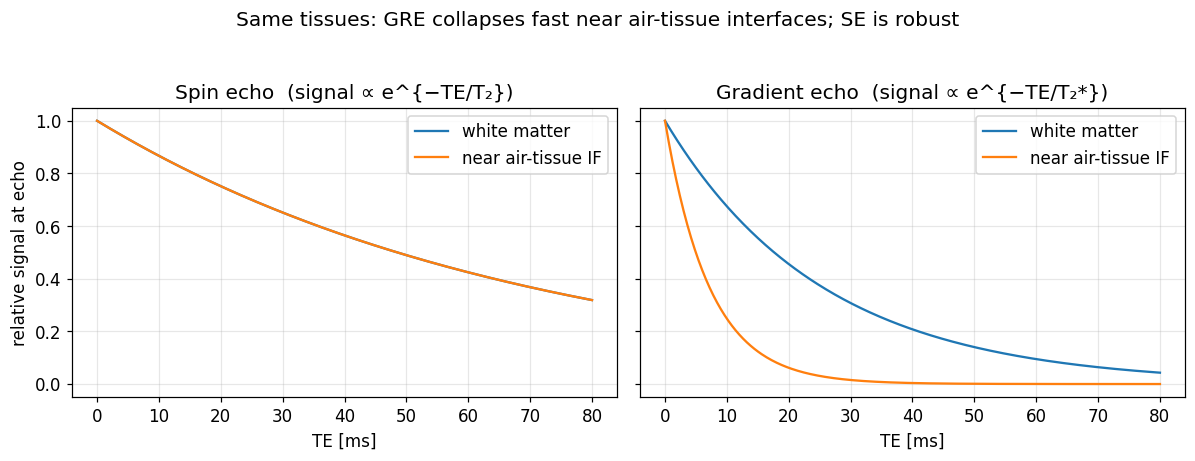

In [8]:
TE_axis = np.linspace(0, 80e-3, 400)
tissues = {                     # (T2 ms, T2prime ms)
    "white matter":      (70e-3, 40e-3),
    "near air-tissue IF":(70e-3,  8e-3),   # large dB(r) -> very short T2'
}
fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)
for name,(T2,T2p) in tissues.items():
    T2s = 1/(1/T2+1/T2p)
    axes[0].plot(TE_axis*1e3, np.exp(-TE_axis/T2),  label=name)   # SE -> T2
    axes[1].plot(TE_axis*1e3, np.exp(-TE_axis/T2s), label=name)   # GRE -> T2*
axes[0].set_title("Spin echo  (signal ∝ e^{−TE/T₂})")
axes[1].set_title("Gradient echo  (signal ∝ e^{−TE/T₂*})")
for ax in axes: ax.set_xlabel("TE [ms]"); ax.legend()
axes[0].set_ylabel("relative signal at echo")
plt.suptitle("Same tissues: GRE collapses fast near air-tissue interfaces; SE is robust", y=1.04)
plt.tight_layout(); plt.show()

## Exercise 13.1 — `T₂'` of a voxel with a linear `ΔB_z`

**Setup.** Box voxel `L×L×L`, uniform `|M'⊥| = M_const`, off-resonance linear in `x`:
`ΔB_z(r) ≈ ΔB_z(r₁) + G_x (x − x₁)`. The signal is

$$S(t)=\int_{\text{voxel}} M'_\perp(\mathbf r,t)\,d^3r
      = M_{\text{const}}L^2 e^{i\gamma \Delta B_z(\mathbf r_1)t}\!\!\int_{-L/2}^{L/2}\!\! e^{\,i\gamma G_x u\,t}\,du
      = M_{\text{const}}L^3\,e^{i\gamma\Delta B_z(\mathbf r_1)t}\,\operatorname{sinc}\!\Big(\tfrac{\gamma G_x L\,t}{2}\Big),$$

with `sinc(a)=sin(a)/a`.

**Is it an exponential, as the lecture states?** **No.** It is a **sinc** — it oscillates and even
goes negative. The `exp(−t/T₂')` of the lecture is an approximation (exact only for a *Lorentzian*
off-resonance spread, cf. Section 2).

**Reasonable `T₂'`.** The spread of frequencies across the voxel is `Δω_FW = γ G_x L`. Setting the
dimensionless argument to 1 gives a natural definition:

$$\boxed{T_2' \equiv \frac{2}{\gamma G_x L}}\quad\Rightarrow\quad T_2'\propto \frac1L.$$

So **doubling the voxel size halves `T₂'`** (more internal dephasing → faster decay).

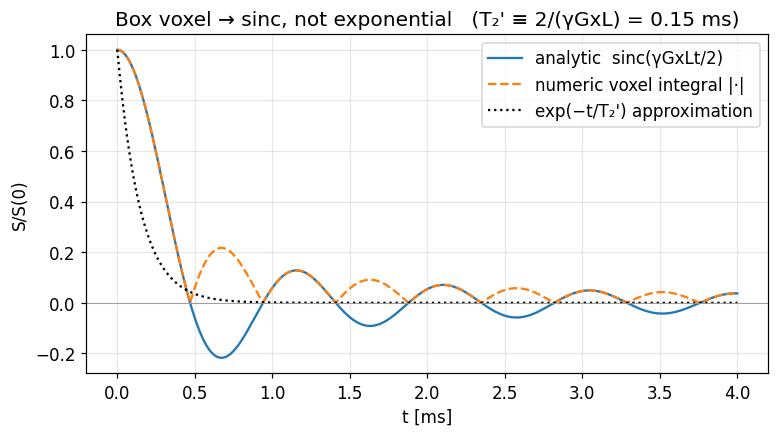

First zero of the sinc at t = 2π/(γGxL) = 0.47 ms


In [9]:
# Verify the analytic sinc against a direct 3D voxel integral
L    = 2e-3                 # 2 mm voxel
Gx   = 50e-6 / L            # tesla/m  -> chosen so dBz varies 50 uT across the voxel
M    = 1.0
t    = np.linspace(0, 4e-3, 800)

# analytic magnitude (drop the constant-offset phase; it doesn't affect |S|)
arg  = GAMMA*Gx*L*t/2
S_analytic = M*L**3*np.sinc(arg/np.pi)        # np.sinc(x)=sin(pi x)/(pi x)

# numerical: integrate exp(i*gamma*Gx*(x-x1)*t) over the box (x only matters)
x = np.linspace(-L/2, L/2, 400)
S_numeric = M*L**2*np.trapezoid(np.exp(1j*GAMMA*Gx*np.outer(t, x)), x, axis=1)

T2p = 2/(GAMMA*Gx*L)
plt.figure()
plt.plot(t*1e3, S_analytic/(M*L**3), label="analytic  sinc(γGxLt/2)")
plt.plot(t*1e3, np.abs(S_numeric)/(M*L**3), "--", label="numeric voxel integral |·|")
plt.plot(t*1e3, np.exp(-t/T2p), ":", color="k", label="exp(−t/T₂') approximation")
plt.axhline(0, color="0.6", lw=0.6)
plt.xlabel("t [ms]"); plt.ylabel("S/S(0)"); plt.legend()
plt.title(f"Box voxel → sinc, not exponential   (T₂' ≡ 2/(γGxL) = {T2p*1e3:.2f} ms)")
plt.show()
print(f"First zero of the sinc at t = 2π/(γGxL) = {2*np.pi/(GAMMA*Gx*L)*1e3:.2f} ms")

In [10]:
# Voxel-size dependence: double L -> half T2'
for Lv in (L, 2*L):
    T2p_v = 2/(GAMMA*Gx*Lv)
    print(f"L = {Lv*1e3:.0f} mm  ->  T2' = {T2p_v*1e3:.2f} ms")
print("\nDoubling the voxel HALVES T2' (faster intra-voxel dephasing).")

L = 2 mm  ->  T2' = 0.15 ms
L = 4 mm  ->  T2' = 0.07 ms

Doubling the voxel HALVES T2' (faster intra-voxel dephasing).


**SNR — is "SNR ∝ voxel size" still true for `T₂*`-weighted sequences?**

Base SNR grows with voxel *volume* (more spins → more signal). But a bigger voxel also has a wider
internal `ΔB` spread, so `T₂'` shrinks (`∝ 1/L`) and the signal *at the echo time* is more attenuated
by the sinc/`T₂*` dephasing. The two effects fight each other:

- **Spin echo (`T₂`-weighted):** the `T₂'` dephasing is refocused at `TE`, so the SNR gain from a
  larger voxel survives → **"SNR ∝ voxel size" holds.**
- **Gradient echo (`T₂*`-weighted):** the dephasing is *not* refocused; a larger voxel loses extra
  signal at `TE`. So the naive **"SNR ∝ voxel size" does *not* hold straightforwardly** — the larger
  voxel partly dephases away its own advantage.

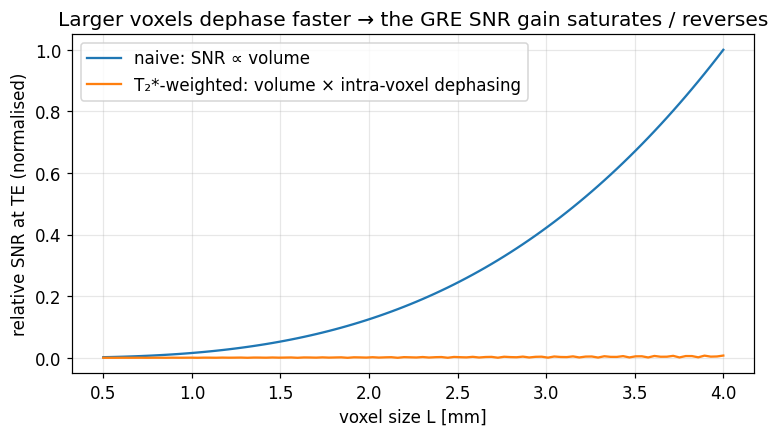

In [11]:
# Illustrate the SNR trade-off at a fixed TE for a T2*-weighted (GRE) readout
TE = 10e-3
Ls = np.linspace(0.5e-3, 4e-3, 100)
base_SNR   = (Ls/Ls[0])**3                        # ∝ volume
T2p_L      = 2/(GAMMA*Gx*Ls)
attenuation= np.abs(np.sinc(GAMMA*Gx*Ls*TE/2/np.pi))   # intra-voxel dephasing at TE
effective  = base_SNR*attenuation

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(Ls*1e3, base_SNR/base_SNR.max(), label="naive: SNR ∝ volume")
ax.plot(Ls*1e3, effective/base_SNR.max(), label="T₂*-weighted: volume × intra-voxel dephasing")
ax.set_xlabel("voxel size L [mm]"); ax.set_ylabel("relative SNR at TE (normalised)")
ax.legend(); ax.set_title("Larger voxels dephase faster → the GRE SNR gain saturates / reverses")
plt.show()

## Exercise 13.2 — k-space and the spin echo

**Setup.** 90° pulse with `B₁⁺ ∥ +y'`; gradient pulses build up some `k₁`; then a 180° pulse with
`B₁⁺ ∥ x'`. Relaxation and inhomogeneity neglected. **Find `k` after the 180°.**

After the gradients, a spin at `r` carries phase `M₊(r) ∝ e^{−i 2π k₁·r}`. A 180° rotation about
`x'` sends `(M_x,M_y,M_z) → (M_x,−M_y,−M_z)`, i.e. it **conjugates** the transverse magnetization:

$$M_+ = M_x + iM_y \;\longrightarrow\; M_x - iM_y = M_+^{*}.$$

Conjugating the spatial phase flips its sign:

$$e^{-i2\pi \mathbf k_1\cdot\mathbf r}\;\longrightarrow\;e^{+i2\pi\mathbf k_1\cdot\mathbf r}
   = e^{-i2\pi(-\mathbf k_1)\cdot\mathbf r}
   \quad\Rightarrow\quad \boxed{\mathbf k \to -\mathbf k_1}.$$

The 180° pulse **reflects k-space through the origin**. That is *exactly* why the echo refocuses:
playing the same gradient afterwards carries `k` from `−k₁` back through `0` (the echo) to `+k₁`.

In [12]:
# Demonstrate k -> -k1 on a 1D phantom
x   = np.linspace(-0.1, 0.1, 1024)        # m
rho = (np.abs(x) < 0.03).astype(float)    # a box object
k1  = 300.0                               # 1/m, the prepared k after gradients

def kspace_center_of(signal_phase):
    # estimate k from the phase ramp slope:  phase = -2*pi*k*x
    p = np.unwrap(np.angle(signal_phase))
    slope = np.polyfit(x[rho>0], p[rho>0], 1)[0]
    return -slope/(2*np.pi)

m_after_grad = rho*np.exp(-1j*2*np.pi*k1*x)        # M+(r) after gradients -> k=+k1
m_after_180  = np.conjugate(m_after_grad)          # 180° about x' : conjugation

print(f"k before 180° : {kspace_center_of(m_after_grad):+.1f} 1/m   (expected +{k1:.0f})")
print(f"k after  180° : {kspace_center_of(m_after_180):+.1f} 1/m   (expected -{k1:.0f})")
print("\n=> The 180° pulse maps k1 -> -k1, the reflection that produces the spin echo.")

k before 180° : +300.0 1/m   (expected +300)
k after  180° : -300.0 1/m   (expected -300)

=> The 180° pulse maps k1 -> -k1, the reflection that produces the spin echo.


## Try it on real data (optional)

Everything above used synthetic spins. To see `T₂*` dropout for real:

- **IXI** (healthy brains, T1/T2/PD): compare a `T₂`-weighted SE and a `T₂*`-weighted GRE near the
  frontal sinus and ear canals — the GRE shows signal voids the SE doesn't.
- **fastMRI**: raw k-space; you can verify the `k → −k` symmetry of a spin-echo acquisition directly.

## Self-test recap (answers in `L13_summary.md`)

1. Why does the *four-spin* toy voxel show revivals, but a broad Gaussian spread decays smoothly?
2. For which line shape is `exp(−t/T₂')` **exact**? What does a box voxel give instead?
3. Re-derive `T₂* = (1/T₂ + 1/T₂')⁻¹` and confirm `T₂*` is the fastest decay.
4. In the spin-echo cell, why does the **echo peak** land on the `T₂` curve and not `T₂*`?
5. Change `T2p` (off-resonance) in the SE cell — does the echo height move? Why / why not?
6. In Exercise 13.1, what happens to the first zero of the sinc if you double `G_x`?
7. In Exercise 13.2, what `k` would you get for a 180° pulse about `y'` instead of `x'`?
